# 05 v2 · Hypnodensity–feature correlations

Este notebook usa el análisis pooled como análisis principal: todas las épocas y todos los electrodos monoelectrodo disponibles se analizan conjuntamente. Los análisis por electrodo y por segmento se conservan únicamente como análisis de sensibilidad numérico, para comprobar si la relación entre las probabilidades inferidas por GSSC y los features depende del canal o de la etapa del registro.

Se incluyen únicamente GSSC, las probabilidades de W/N1/R y la entropía normalizada. Se excluyen todos los features de YASA; el conjunto queda restringido a bandpower, Catch22 y SpecParam.

## i) Imports, parámetros y estilo gráfico

Se reciclan las funciones de ensamblado, unión, correlación y exportación del proyecto. Las figuras se exportan en PNG, SVG y PDF, con la configuración tipográfica Liberation Sans usada en el notebook 02. No se usan suptitles.

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from dmt_hypnodensities import (
    add_hypnodensity_entropy, assemble_outputs, feature_value_columns,
    join_epoch_features_hypnodensities, load_config, save_figure, save_table,
    stage_feature_effect_correlations,
)

plt.rcParams.update({
    'font.family': 'Liberation Sans', 'font.sans-serif': ['Liberation Sans'], 'font.size': 14,
    'axes.titlesize': 14, 'axes.labelsize': 13, 'xtick.labelsize': 10,
    'ytick.labelsize': 10, 'legend.fontsize': 11, 'svg.fonttype': 'none',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})
sns.set_theme(style='whitegrid', font='Liberation Sans')
CONFIG_PATH = next(p.resolve() for p in (Path('configs/analysis.yaml'), Path('../configs/analysis.yaml')) if p.is_file())
RUN_NAME = 'gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1'
RESULTS_NAME = 'feature_hypnodensity_correlations_000s_gssc_v2'
STAGER = 'gssc'
STAGES = ('W', 'N1', 'R', 'entropy')
RESPONSE_COLUMNS = ('prob_W', 'prob_N1', 'prob_R', 'entropy')
PHASES, DOSES = ('before', 'after'), ('placebo', 'DMT')
CORRELATION_METHOD, MIN_OBSERVATIONS, TOP_N = 'spearman', 30, 10
RUN_ROOT = load_config(CONFIG_PATH).output_dir / RUN_NAME
TABLES_DIR = load_config(CONFIG_PATH).output_dir / RESULTS_NAME / 'tables'
FIGURES_DIR = load_config(CONFIG_PATH).output_dir / RESULTS_NAME / 'figures'
TABLES_DIR.mkdir(parents=True, exist_ok=True); FIGURES_DIR.mkdir(parents=True, exist_ok=True)
tables = assemble_outputs(RUN_ROOT / 'recordings', strict=True)
display({'run': RUN_NAME, 'n_feature_rows': len(tables.features), 'n_hypnodensity_rows': len(tables.hypnodensities)})


## ii) Selección de features y categorías Catch22

Las categorías de Catch22 se toman de la tabla oficial de descripciones. Bandpower y SpecParam se mantienen como categorías propias. El color de categoría se aplicará de forma consistente a las etiquetas de todas las figuras.

In [ ]:
CATCH22_CATEGORIES = {
    'c22_DN_HistogramMode_5':'Distribution shape', 'c22_DN_HistogramMode_10':'Distribution shape',
    'c22_DN_OutlierInclude_p_001_mdrmd':'Extreme event timing', 'c22_DN_OutlierInclude_n_001_mdrmd':'Extreme event timing',
    'c22_CO_f1ecac':'Linear autocorrelation', 'c22_CO_FirstMin_ac':'Linear autocorrelation',
    'c22_SP_Summaries_welch_rect_area_5_1':'Linear autocorrelation', 'c22_SP_Summaries_welch_rect_centroid':'Linear autocorrelation',
    'c22_FC_LocalSimple_mean3_stderr':'Simple forecasting', 'c22_FC_LocalSimple_mean1_tauresrat':'Incremental differences',
    'c22_MD_hrv_classic_pnn40':'Incremental differences', 'c22_SB_BinaryStats_mean_longstretch1':'Symbolic',
    'c22_SB_BinaryStats_diff_longstretch0':'Symbolic', 'c22_SB_MotifThree_quantile_hh':'Symbolic',
    'c22_SB_TransitionMatrix_3ac_sumdiagcov':'Symbolic', 'c22_CO_HistogramAMI_even_2_5':'Nonlinear autocorrelation',
    'c22_CO_trev_1_num':'Nonlinear autocorrelation', 'c22_IN_AutoMutualInfoStats_40_gaussian_fmmi':'Linear autocorrelation structure',
    'c22_PD_PeriodicityWang_th0_01':'Linear autocorrelation structure', 'c22_CO_Embed2_Dist_tau_d_expfit_meandiff':'Other',
    'c22_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1':'Self-affine scaling',
    'c22_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1':'Self-affine scaling',
}
CATEGORY_COLORS = {'Bandpower':'#7a5195', 'Distribution/autocorrelation':'#f2a900', 'Dynamics':'#2a9d8f', 'Symbolic':'#6a994e', 'Scaling/other':'#bc6c25', 'SpecParam':'#8c6d5a'}
def feature_category(feature):
    if feature.startswith('bp_'): return 'Bandpower'
    if feature.startswith('specparam_'): return 'SpecParam'
    category = CATCH22_CATEGORIES.get(feature)
    if category in {'Distribution shape','Extreme event timing','Linear autocorrelation','Linear autocorrelation structure','Nonlinear autocorrelation'}: return 'Distribution/autocorrelation'
    if category in {'Simple forecasting','Incremental differences'}: return 'Dynamics'
    if category == 'Symbolic': return 'Symbolic'
    if category in {'Self-affine scaling','Other'}: return 'Scaling/other'
    raise KeyError(f'Feature without category: {feature}')
ALL_FEATURES = feature_value_columns(tables.features)
FEATURES = tuple(f for f in ALL_FEATURES if f.startswith(('bp_', 'c22_', 'specparam_')))
FEATURE_CATEGORY = {f: feature_category(f) for f in FEATURES}
missing = sorted(f for f in FEATURES if f.startswith('c22_') and f not in CATCH22_CATEGORIES)
if missing: raise KeyError(f'Catch22 columns missing from category map: {missing}')
display(pd.Series(FEATURE_CATEGORY, name='category').rename_axis('feature').to_frame())


## iii) Tabla analítica a nivel de época

Se añade entropía normalizada a partir de las cinco probabilidades y se filtra GSSC. Se conservan los metadatos de electrodo, fase y condición para los tests de sensibilidad posteriores.

In [ ]:
epoch_analysis = join_epoch_features_hypnodensities(tables.features, add_hypnodensity_entropy(tables.hypnodensities), strict=True)
epoch_analysis = epoch_analysis.loc[epoch_analysis['stager'].astype(str).eq(STAGER)].copy()
save_table(epoch_analysis, TABLES_DIR / 'epoch_feature_hypnodensity_filtered.parquet')
display(epoch_analysis.shape)


## iv) Análisis principal pooled y ranking por W

La correlación pooled usa todas las observaciones disponibles. El ranking se define exclusivamente con prob_W y se reutiliza en todos los resultados posteriores.

In [ ]:
pooled_correlations = stage_feature_effect_correlations(epoch_analysis, stage_columns=RESPONSE_COLUMNS, feature_columns=FEATURES, group_by=('stager',), methods=(CORRELATION_METHOD,), min_observations=MIN_OBSERVATIONS)
pooled_correlations = pooled_correlations.loc[pooled_correlations['stager'].astype(str).eq(STAGER)].copy()
save_table(pooled_correlations, TABLES_DIR / 'pooled_feature_probability_correlations.csv')
pooled_matrix = pooled_correlations.pivot(index='stage', columns='feature', values='correlation').reindex(STAGES)
feature_order = pooled_matrix.loc['W'].sort_values(ascending=False, na_position='last').index.tolist()
ranked_matrix = pooled_matrix.loc[:, feature_order]
display(ranked_matrix)


## v) Analysis 6 — Feature ranking heatmap, ordered by wakefulness correlation

El primer plot muestra las cuatro respuestas y las features ordenadas por la correlación pooled con W. El color de las etiquetas codifica la categoría del feature.

In [ ]:
def category_legend(axis):
    handles = [plt.Line2D([0],[0], marker='s', linestyle='', color=c, markersize=9, label=k) for k,c in CATEGORY_COLORS.items()]
    axis.legend(handles=handles, title='Feature category', bbox_to_anchor=(0.5,1.16), loc='lower center', ncol=len(handles), frameon=False, columnspacing=1.0, handletextpad=0.35)
figure, axis = plt.subplots(figsize=(max(12, .42*len(feature_order)), 5.5), constrained_layout=True)
image = axis.imshow(ranked_matrix.to_numpy(float), vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
axis.set_xticks(np.arange(len(feature_order)), feature_order, rotation=75, ha='right'); axis.set_yticks(np.arange(len(STAGES)), STAGES)
axis.set_xlabel('Features (ordered by pooled W correlation)'); axis.set_ylabel('')
axis.set_xticks(np.arange(-.5, len(feature_order), 1), minor=True); axis.set_yticks(np.arange(-.5, len(STAGES), 1), minor=True)
axis.grid(False, which='major'); axis.grid(which='minor', color='white', linewidth=1.2); axis.tick_params(which='minor', bottom=False, left=False)
for label, feature in zip(axis.get_xticklabels(), feature_order): label.set_color(CATEGORY_COLORS[FEATURE_CATEGORY[feature]])
figure.colorbar(image, ax=axis, label='Spearman correlation r'); category_legend(axis)
save_figure(figure, FIGURES_DIR / '01_pooled_feature_ranking_heatmap', formats=('png','svg','pdf')); plt.show()


## vi) Sensitivity analysis: electrodos y segmentos

Se repiten las correlaciones agrupando por electrodo, por fase × condición y por electrodo × fase × condición. Estos subanálisis se reportan solo numéricamente. Para cada respuesta se resume la similitud con el vector pooled mediante r entre vectores, diferencia absoluta media y diferencia absoluta máxima.

In [ ]:
segment_table = epoch_analysis.loc[epoch_analysis['experimental_label'].astype(str).isin(PHASES) & epoch_analysis['condition'].astype(str).isin(DOSES)].copy()
specs = {'pooled':(epoch_analysis,('stager',)), 'electrode':(epoch_analysis,('stager','electrode')), 'segment':(segment_table,('stager','experimental_label','condition')), 'electrode × segment':(segment_table,('stager','electrode','experimental_label','condition'))}
correlation_tables = {}
for scope,(data,groups) in specs.items():
    result = stage_feature_effect_correlations(data, stage_columns=RESPONSE_COLUMNS, feature_columns=FEATURES, group_by=groups, methods=(CORRELATION_METHOD,), min_observations=MIN_OBSERVATIONS)
    result['analysis_scope'] = scope; correlation_tables[scope] = result
    save_table(result, TABLES_DIR / f'{scope.replace(" × ","_").replace(" ","_")}_correlations.csv')
pooled_lookup = pooled_correlations.set_index(['stage','feature'])['correlation']
rows = []
for scope,result in correlation_tables.items():
    for stage in STAGES:
        current = result.loc[result['stage'].eq(stage)].copy()
        if scope == 'pooled': vectors = current[['feature','correlation']].assign(group='pooled')
        else:
            group_columns = [c for c in specs[scope][1] if c != 'stager']
            vectors = current.pivot_table(index=group_columns, columns='feature', values='correlation').reset_index().melt(id_vars=group_columns, var_name='feature', value_name='correlation')
            vectors['group'] = vectors[group_columns].astype(str).agg(' | '.join, axis=1)
        vectors['pooled'] = vectors['feature'].map(lambda f: pooled_lookup.get((stage,f), np.nan)); valid = vectors.dropna(subset=['correlation','pooled'])
        rows.append({'analysis_scope':scope,'response':stage,'n_group_vectors':vectors['group'].nunique(),'n_feature_values':len(valid),'vector_r_vs_pooled':1.0 if scope=='pooled' else valid['correlation'].corr(valid['pooled']),'mean_abs_delta_r':(valid['correlation']-valid['pooled']).abs().mean(),'max_abs_delta_r':(valid['correlation']-valid['pooled']).abs().max()})
sensitivity_summary = pd.DataFrame(rows); save_table(sensitivity_summary, TABLES_DIR / 'sensitivity_summary.csv')
display(sensitivity_summary.style.format({'vector_r_vs_pooled':'{:.3f}','mean_abs_delta_r':'{:.3f}','max_abs_delta_r':'{:.3f}'}))


## vii) Grilla de jointplots hexagonales para los extremos del ranking W

Las diez columnas son los cinco features más positivos y los cinco más negativos según W. Cada fila corresponde a W, N1, R o entropía. Cada panel muestra únicamente la densidad conjunta en hexágonos, sin puntos individuales ni marginales, para mantener la figura ligera y editable.

In [ ]:
import textwrap
scatter_features = feature_order[:5] + feature_order[-5:]
figure, axes = plt.subplots(len(STAGES), len(scatter_features), figsize=(25,11), squeeze=False, constrained_layout=True)
for row,(axis_row,stage,response) in enumerate(zip(axes,STAGES,RESPONSE_COLUMNS)):
    for col,(axis,feature) in enumerate(zip(axis_row,scatter_features)):
        data = epoch_analysis[[response,feature]].replace([np.inf,-np.inf],np.nan).dropna()
        color = CATEGORY_COLORS[FEATURE_CATEGORY[feature]]
        axis.hexbin(data[feature], data[response], gridsize=18, mincnt=1,
                    bins='log', cmap='gray', linewidths=0, edgecolors='none')
        axis.set_title(textwrap.fill(feature, width=14) if row==0 else '', color=color, rotation=0, ha='center', va='bottom', fontsize=7, pad=5)
        axis.set_xlabel(feature if row==len(STAGES)-1 else '', fontsize=8); axis.set_ylabel(stage if col==0 else ''); axis.tick_params(labelsize=7)
figure.supxlabel('Feature value'); figure.supylabel('Hypnodensity response')
save_figure(figure, FIGURES_DIR / '02_top_bottom_W_features_scatter_grid', formats=('png','svg','pdf')); plt.show()


### vii.b) Jointplots hexagonales con escala logarítmica

Se repite la misma grilla de densidades conjuntas con escala logarítmica en el eje de la probabilidad. El rango se fija entre 10⁻⁶ y 1 para visualizar también probabilidades muy pequeñas.

In [ ]:
figure, axes = plt.subplots(len(STAGES), len(scatter_features), figsize=(25,11), squeeze=False, constrained_layout=True)
for row,(axis_row,stage,response) in enumerate(zip(axes,STAGES,RESPONSE_COLUMNS)):
    for col,(axis,feature) in enumerate(zip(axis_row,scatter_features)):
        data = epoch_analysis[[response,feature]].replace([np.inf,-np.inf],np.nan).dropna()
        color = CATEGORY_COLORS[FEATURE_CATEGORY[feature]]
        axis.hexbin(data[feature], data[response], gridsize=18, mincnt=1, bins='log', cmap='viridis', linewidths=0, edgecolors='none')
        axis.set_yscale('log'); axis.set_ylim(1e-6, 1)
        axis.set_title(textwrap.fill(feature, width=14) if row==0 else '', color=color, rotation=0, ha='center', va='bottom', fontsize=7, pad=5)
        axis.set_xlabel(feature if row==len(STAGES)-1 else '', fontsize=8); axis.set_ylabel(stage if col==0 else ''); axis.tick_params(labelsize=7)
figure.supxlabel('Feature value'); figure.supylabel('Hypnodensity response (log scale)')
save_figure(figure, FIGURES_DIR / '02b_top_bottom_W_features_hexbin_log_probability', formats=('png','svg','pdf')); plt.show()


## viii) Analysis 7 — Condition split for top y bottom W-correlated features

Se conserva la figura del notebook original usando los features filtrados. Los nombres de features se colorean con la misma codificación de categorías.

In [ ]:
condition_features = scatter_features
subject_phase_means = segment_table.groupby(['subject','condition','experimental_label'], observed=True)[condition_features].mean().reset_index()
standardized = subject_phase_means.copy(); standardized[condition_features] = (standardized[condition_features]-standardized[condition_features].mean())/standardized[condition_features].std()
plot_data = standardized.melt(id_vars=['subject','condition','experimental_label'], value_vars=condition_features, var_name='feature', value_name='z_score')
palette={'placebo':'#6b7280','DMT':'#c2410c'}; offsets={'placebo':-.16,'DMT':.16}
figure,axes=plt.subplots(1,len(PHASES),figsize=(14,7),squeeze=False,sharey=True,constrained_layout=True)
for axis,phase in zip(axes[0],PHASES):
    subset=plot_data.loc[plot_data['experimental_label'].astype(str).eq(phase)]
    sns.violinplot(data=subset,x='feature',y='z_score',hue='condition',order=condition_features,hue_order=list(DOSES),split=True,inner=None,palette=palette,cut=0,density_norm='width',gap=.08,fill=True,linewidth=0,ax=axis,alpha=.2)
    axis.axhline(0,color='#374151',linewidth=1,linestyle='--'); axis.set_title(phase.capitalize()); axis.set_xlabel(''); axis.set_ylabel('Standardized value (z-score)' if axis is axes[0,0] else ''); axis.tick_params(axis='x',rotation=75,labelsize=8)
    for label,feature in zip(axis.get_xticklabels(),condition_features): label.set_color(CATEGORY_COLORS[FEATURE_CATEGORY[feature]]); label.set_ha('right')
    legend=axis.get_legend()
    if legend is not None:
        if axis is axes[0,0]: legend.set_title(None)
        else: legend.remove()
    for position,feature in enumerate(condition_features):
        subset_feature=subset.loc[subset['feature'].eq(feature)]; paired=subset_feature.pivot(index='subject',columns='condition',values='z_score').dropna(subset=list(DOSES),how='any')
        for _,subject in paired.iterrows(): axis.plot([position+offsets['placebo'],position+offsets['DMT']],[subject['placebo'],subject['DMT']],color='black',linewidth=1,zorder=3)
        for dose in DOSES:
            values=subset_feature.loc[subset_feature['condition'].eq(dose),'z_score']; axis.scatter(np.full(len(values),position+offsets[dose]),values,s=48,color=palette[dose],edgecolor='none',alpha=.5,zorder=4)
save_figure(figure, FIGURES_DIR / '03_top_bottom_features_by_condition', formats=('png','svg','pdf')); plt.show()


## ix) Participación de categorías en el top 10

Cada pastel muestra la participación de las categorías en los diez features más positivos o más negativos. Las columnas son W, N1, R y entropía.

In [ ]:
figure,axes=plt.subplots(2,len(STAGES),figsize=(16,5.5),squeeze=False, gridspec_kw={'hspace':.05,'wspace':.15})
for row,direction in enumerate(('positive','negative')):
    for col,stage in enumerate(STAGES):
        axis=axes[row,col]; stage_data=pooled_correlations.loc[pooled_correlations['stage'].eq(stage)].dropna(subset=['correlation'])
        selected=stage_data.nlargest(TOP_N,'correlation') if direction=='positive' else stage_data.nsmallest(TOP_N,'correlation')
        counts=selected['feature'].map(FEATURE_CATEGORY).value_counts(); colors=[CATEGORY_COLORS[c] for c in counts.index]
        axis.pie(counts.values, labels=None, colors=colors, autopct='%1.0f%%', startangle=90, textprops={'fontsize':10})
        axis.set_title(f'{stage} · {direction}', pad=4)
handles = [plt.Line2D([0],[0], marker='s', linestyle='', color=color, markersize=9, label=category) for category,color in CATEGORY_COLORS.items()]
figure.legend(handles=handles, labels=list(CATEGORY_COLORS), loc='lower center', bbox_to_anchor=(.5,.01), ncol=len(handles), frameon=False, columnspacing=1.0, handletextpad=.35)
figure.subplots_adjust(bottom=.18, top=.88)
save_figure(figure, FIGURES_DIR / '04_category_participation_top_bottom10', formats=('png','svg','pdf')); plt.show()


## x) Archivos generados

Las tablas completas y el resumen de sensibilidad se guardan en tables/; las cuatro figuras se guardan en figures/ dentro del directorio de resultados de esta v2.

In [ ]:
display({'tables_directory': str(TABLES_DIR), 'figures_directory': str(FIGURES_DIR), 'n_selected_features': len(FEATURES), 'n_ranked_features': len(feature_order)})

## xi) LME de asociaciones entre cambios en features y cambios en hipnodensidades

Para evaluar si los cambios inducidos por DMT en los features se asocian con los cambios en las hipnodensidades, se calculan primero los deltas DMT − placebo dentro de cada sujeto, fase y electrodo. Las épocas no necesitan estar emparejadas: se comparan las medias de cada celda experimental.

Se ajusta el mismo tipo de LME usado en el notebook 02: delta de hipnodensidad como respuesta, delta del feature, fase y su interacción como efectos fijos, intercepto aleatorio por sujeto y componente de varianza por electrodo. Antes del ajuste, cada delta de feature se estandariza usando la media y desviación estándar de todos los deltas disponibles en before, after y late. Por tanto, los β se interpretan por un cambio de una desviación estándar del feature. Se reportan por separado las interacciones con after y late.

In [ ]:
import warnings
import statsmodels.formula.api as smf

DELTA_PHASES = ('before', 'after', 'late')
delta_source = epoch_analysis.loc[
    epoch_analysis['experimental_label'].astype(str).isin(DELTA_PHASES)
    & epoch_analysis['condition'].astype(str).isin(DOSES)
].copy()
delta_means = (
    delta_source.groupby(['subject', 'condition', 'experimental_label', 'electrode'], observed=True)[
        list(RESPONSE_COLUMNS) + list(FEATURES)
    ].mean().reset_index()
)
delta_keys = ['subject', 'experimental_label', 'electrode']
dmt = delta_means.loc[delta_means['condition'].astype(str).eq('DMT')].drop(columns='condition').set_index(delta_keys)
placebo = delta_means.loc[delta_means['condition'].astype(str).eq('placebo')].drop(columns='condition').set_index(delta_keys)
common_keys = dmt.index.intersection(placebo.index)
delta_data = (dmt.loc[common_keys] - placebo.loc[common_keys]).reset_index()
delta_data['phase'] = pd.Categorical(delta_data['experimental_label'].astype(str), categories=DELTA_PHASES, ordered=True)
feature_delta_mean = delta_data[list(FEATURES)].mean()
feature_delta_sd = delta_data[list(FEATURES)].std()
delta_data[list(FEATURES)] = (delta_data[list(FEATURES)] - feature_delta_mean) / feature_delta_sd
display({
    'delta_rows': len(delta_data),
    'subjects_by_phase': delta_data.groupby('phase', observed=True)['subject'].nunique().to_dict(),
    'complete_subjects_all_phases': int(delta_data.groupby('subject')['phase'].nunique().eq(len(DELTA_PHASES)).sum()),
})

def bh_adjust(p_values):
    values = np.asarray(p_values, dtype=float)
    adjusted = np.full(values.shape, np.nan)
    finite = np.flatnonzero(np.isfinite(values))
    if finite.size:
        order = np.argsort(values[finite])
        sorted_values = values[finite][order]
        sorted_adjusted = sorted_values * finite.size / np.arange(1, finite.size + 1)
        sorted_adjusted = np.minimum.accumulate(sorted_adjusted[::-1])[::-1]
        adjusted[finite[order]] = np.minimum(sorted_adjusted, 1.0)
    return adjusted

lme_rows = []
for feature in FEATURES:
    for response in RESPONSE_COLUMNS:
        data = delta_data[['subject', 'electrode', 'phase', feature, response]].replace([np.inf, -np.inf], np.nan).dropna().rename(columns={feature: 'delta_feature', response: 'delta_response'})
        formula = 'delta_response ~ delta_feature * C(phase, Treatment(reference=\"before\"))'
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            model = smf.mixedlm(formula, data=data, groups=data['subject'], vc_formula={'electrode': '0 + C(electrode)'}, re_formula='1')
            fit = model.fit(reml=False, method='lbfgs', maxiter=400, disp=False)
        confidence = fit.conf_int()
        for phase in ('after', 'late'):
            term = f'delta_feature:C(phase, Treatment(reference=\"before\"))[T.{phase}]'
            lme_rows.append({
                'feature': feature, 'response': response.removeprefix('prob_'), 'contrast': phase,
                'estimate': float(fit.params[term]), 'ci95_low': float(confidence.loc[term, 0]),
                'ci95_high': float(confidence.loc[term, 1]), 'p_value': float(fit.pvalues[term]),
                'n_subjects': int(data['subject'].nunique()), 'n_rows': int(len(data)),
            })

delta_lme_results = pd.DataFrame(lme_rows)
for contrast in ('after', 'late'):
    mask = delta_lme_results['contrast'].eq(contrast)
    delta_lme_results.loc[mask, 'q_fdr'] = bh_adjust(delta_lme_results.loc[mask, 'p_value'])
save_table(delta_lme_results, TABLES_DIR / 'delta_feature_hypnodensity_lme_results.csv')

def display_delta_table(contrast):
    subset = delta_lme_results.loc[delta_lme_results['contrast'].eq(contrast)].copy()
    subset['result'] = subset.apply(lambda row: f"β={row['estimate']:.4g}; IC95% [{row['ci95_low']:.4g}, {row['ci95_high']:.4g}]; p={row['p_value']:.3g}; q={row['q_fdr']:.3g}", axis=1)
    table = subset.pivot(index='feature', columns='response', values='result').reindex(columns=['W', 'N1', 'R', 'entropy'])
    table.columns.name = None
    save_table(table.reset_index(), TABLES_DIR / f'delta_lme_{contrast}_table.csv')
    display(table)

display(Markdown('### LME delta: after'))
display_delta_table('after')
display(Markdown('### LME delta: late'))
display_delta_table('late')


## xii) Volcano plot de las asociaciones LME

Se muestran todos los tests feature–target de cada fase. El color identifica la categoría del feature y la forma identifica el target. Solo se etiquetan los features con −log10(p) > 10, en el target donde presentan el menor p-value dentro de cada fase, con texto envuelto y líneas guía discontinuas cortas. La línea horizontal representa el umbral de p-value equivalente a q-FDR = 0.05.

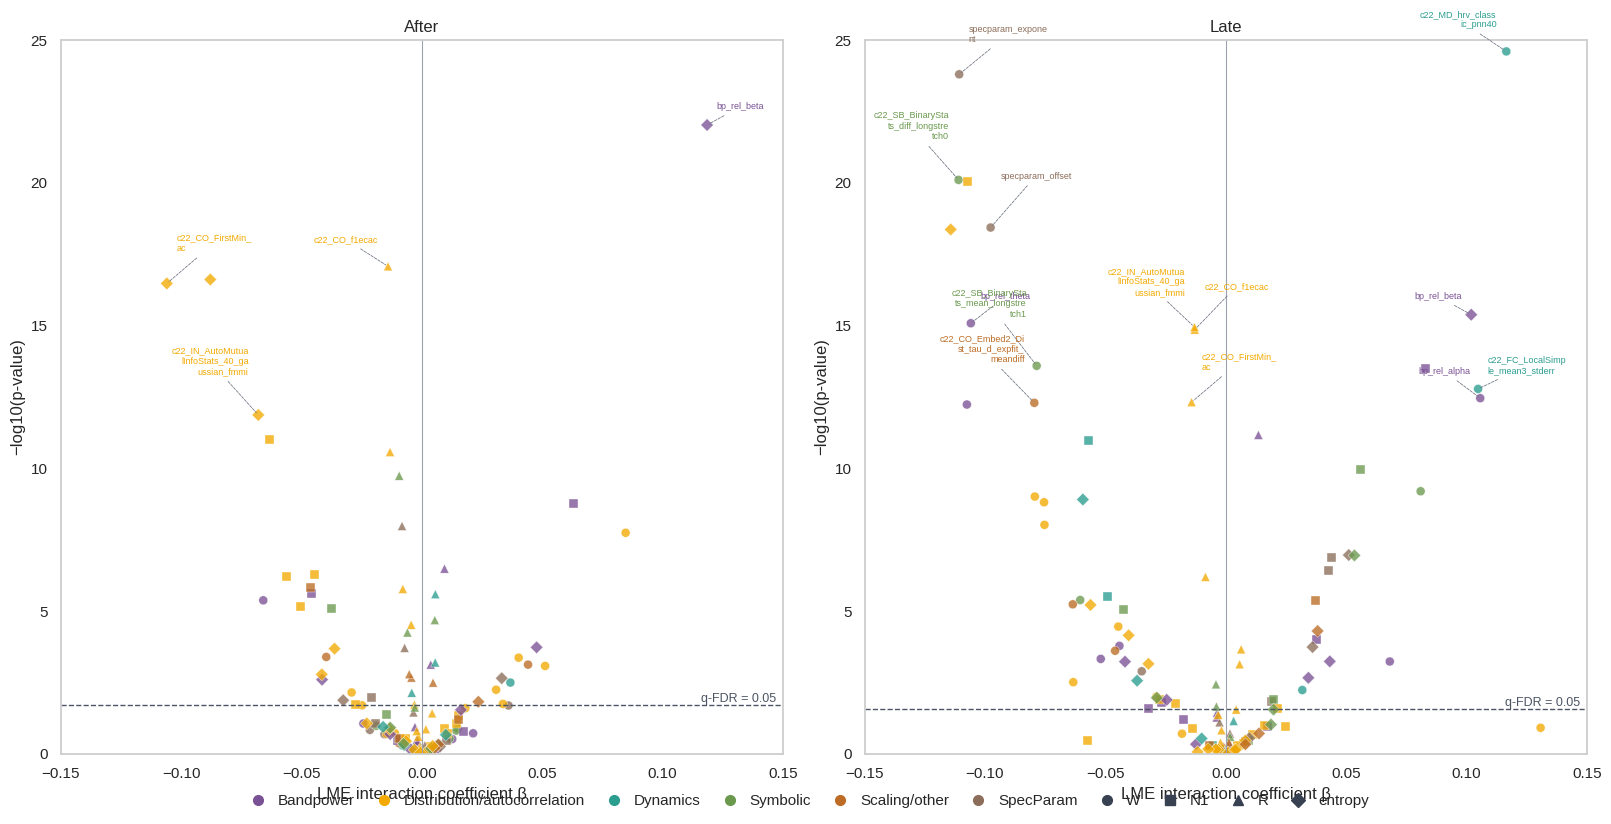

In [22]:
import textwrap
from matplotlib.lines import Line2D

target_markers = {'W': 'o', 'N1': 's', 'R': '^', 'entropy': 'D'}
figure, axes = plt.subplots(1, 2, figsize=(16, 8), squeeze=False, constrained_layout=True)
for axis, contrast in zip(axes[0], ('after', 'late')):
    subset = delta_lme_results.loc[delta_lme_results['contrast'].eq(contrast)].copy()
    subset['neg_log10_p'] = -np.log10(np.clip(subset['p_value'], 1e-300, None))
    for response, marker in target_markers.items():
        target = subset.loc[subset['response'].eq(response)]
        axis.scatter(target['estimate'], target['neg_log10_p'], marker=marker,
                      s=42, alpha=.78, linewidth=.35, edgecolor='white',
                      color=[CATEGORY_COLORS[FEATURE_CATEGORY[f]] for f in target['feature']],
                      label=response)
    significant = subset.loc[subset['q_fdr'].lt(.05)]
    if not significant.empty:
        p_threshold = significant['p_value'].max()
        axis.axhline(-np.log10(p_threshold), color='#4b5563', linewidth=1, linestyle='--')
        axis.text(.99, -np.log10(p_threshold), 'q-FDR = 0.05', transform=axis.get_yaxis_transform(),
                  ha='right', va='bottom', fontsize=9, color='#4b5563')
    # Label each feature once at its most significant target in this phase.
    labels = subset.loc[subset['neg_log10_p'].gt(10)].sort_values('neg_log10_p', ascending=False).drop_duplicates('feature')
    for index, (_, row) in enumerate(labels.iterrows()):
        side = 1 if index % 2 == 0 else -1
        vertical = 10 + (index % 5) * 6
        axis.annotate(textwrap.fill(row['feature'], width=16),
                      xy=(row['estimate'], row['neg_log10_p']),
                      xytext=(side * 7, vertical), textcoords='offset points',
                      ha='left' if side > 0 else 'right', va='bottom', fontsize=6.5,
                      color=CATEGORY_COLORS[FEATURE_CATEGORY[row['feature']]],
                      arrowprops={'arrowstyle': '-', 'linestyle': '--', 'linewidth': .55,
                                  'color': '#6b7280', 'shrinkA': 2, 'shrinkB': 2})
    axis.axvline(0, color='#9ca3af', linewidth=.8)
    axis.set_title(contrast.capitalize())
    axis.set_xlabel('LME interaction coefficient β')
    axis.set_ylabel('−log10(p-value)')
    axis.set_xlim(-0.15, 0.15)
    axis.set_ylim(0, 25)
    axis.grid(False)
category_handles = [Line2D([0], [0], marker='o', linestyle='', color=color, markersize=7, label=category) for category, color in CATEGORY_COLORS.items()]
target_handles = [Line2D([0], [0], marker=marker, linestyle='', color='#374151', markersize=7, label=target) for target, marker in target_markers.items()]
figure.legend(handles=category_handles + target_handles, loc='lower center', bbox_to_anchor=(.5, -.02), ncol=len(category_handles) + len(target_handles), frameon=False, columnspacing=.9, handletextpad=.3)
save_figure(figure, FIGURES_DIR / '05_delta_lme_volcano_after_late', formats=('png','svg','pdf')); plt.show()
